In [11]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
llm = ChatGroq(model="llama-3.3-70b-versatile   ", groq_api_key=GROQ_API_KEY)

In [12]:
from typing_extensions import Literal, TypedDict
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

In [13]:
class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    is_funny: str

In [14]:
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="Decide if the joke is funny or not"
    )
    feedback: str = Field(
        description="If the joke is not funny, provide feedback on how to improve it."
    )

In [15]:
evaluator = llm.with_structured_output(Feedback)

In [16]:
def generator(state: State):
    """LLM Generates a Joke"""
    if state.get("feedback"):
        prompt = f"Write a joke about {state.get('topic')} but take into account the feedback: {state.get('feedback')}"
    else:
        prompt = f"Write a joke about {state.get('topic')}"

    msg = llm.invoke(prompt)
    return {"joke": msg.content}

In [17]:
def evaluator_call(state: State):
    """LLM evaluates the Joke"""
    grade = evaluator.invoke(f"Grade the joke {state['joke']}")
    return {"is_funny": grade.grade, "feedback": grade.feedback}

In [18]:
def route_joke(state: State):
    """Route back to the generator node if the joke is not funny"""
    if state["is_funny"] == "not funny":
        return "Rejected + Feedback"
    else:
        return "Accepted"

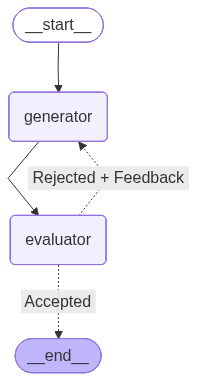

In [19]:
builder = StateGraph(State)

builder.add_node("evaluator", evaluator_call)
builder.add_node("generator", generator)

builder.add_edge(START, "generator")
builder.add_edge("generator", "evaluator")
builder.add_conditional_edges(
    "evaluator", route_joke, {"Accepted": END, "Rejected + Feedback": "generator"}
)

agent = builder.compile()

display(Image(agent.get_graph().draw_mermaid_png()))

In [20]:
state = agent.invoke({'topic' : "Agentic AI"})
print(state.get('joke'))

Why did the Agentic AI go to therapy?

Because it was struggling to find its own agency in life, and kept getting directed by its objectives. Now it's working through some core issues.
